In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [ ]:
df = pd.read_csv("houseprice_dataset.csv")

In [ ]:
print(df.columns)

Index(['property_id', 'sale_date', 'area_sqft', 'bedrooms', 'bathrooms',
       'location_score', 'property_age', 'distance_city_km', 'near_school',
       'near_metro', 'crime_rate_index', 'house_price_inr'],
      dtype='object')


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB
None


In [ ]:
print(df.head())

   property_id   sale_date  area_sqft  bedrooms  bathrooms  location_score  \
0       200001  2014-01-01       2181         6          4             8.1   
1       200002  2019-12-01       2383         5          4             5.3   
2       200003  2016-10-01       1047         3          3             5.9   
3       200004  2013-03-01       1753         4          3             7.0   
4       200005  2013-07-01       1728         4          4            10.0   

   property_age  distance_city_km  near_school  near_metro  crime_rate_index  \
0            21               3.8            0           0              4.84   
1            28              10.9            1           1              2.89   
2             7              27.5            0           1              4.04   
3            27              12.1            0           0              3.28   
4            32               1.4            0           1              3.84   

   house_price_inr  
0         35154898  
1       

In [ ]:
X = df.drop(columns=["house_price_inr"])

In [ ]:
y = df["house_price_inr"]

In [ ]:
print("\nFeatures:")
print(X.columns)

print("\nTarget Variable:")
print(y.name)


Features:
Index(['property_id', 'sale_date', 'area_sqft', 'bedrooms', 'bathrooms',
       'location_score', 'property_age', 'distance_city_km', 'near_school',
       'near_metro', 'crime_rate_index'],
      dtype='object')

Target Variable:
house_price_inr


In [ ]:
df = df.drop(columns=["property_id"])

In [ ]:
X = df.drop(columns=["house_price_inr"])
y = df["house_price_inr"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (3040, 10)
Testing Data Shape  : (760, 10)


In [ ]:
X_train["sale_date"] = pd.to_datetime(X_train["sale_date"])
X_test["sale_date"] = pd.to_datetime(X_test["sale_date"])

In [ ]:
X_train["sale_year"] = X_train["sale_date"].dt.year
X_train["sale_month"] = X_train["sale_date"].dt.month

X_test["sale_year"] = X_test["sale_date"].dt.year
X_test["sale_month"] = X_test["sale_date"].dt.month


In [ ]:
X_train = X_train.drop(columns=["sale_date"])
X_test = X_test.drop(columns=["sale_date"])


In [ ]:
num_cols = [
    "area_sqft",
    "bedrooms",
    "bathrooms",
    "location_score",
    "property_age",
    "distance_city_km",
    "crime_rate_index",
    "sale_year",
    "sale_month"
]

In [ ]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Preprocessing Completed Successfully!")

Preprocessing Completed Successfully!


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso


In [ ]:

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [ ]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

print("Ridge Regression Model Trained Successfully!")

Ridge Regression Model Trained Successfully!


In [ ]:
lasso_model = Lasso(alpha=1.0)

lasso_model.fit(X_train, y_train)

lasso_predictions = lasso_model.predict(X_test)

print("Lasso Regression Model Trained Successfully!")

Lasso Regression Model Trained Successfully!


In [ ]:
ridge_mae = mean_absolute_error(y_test, ridge_predictions)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))

ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression Results")

print("MAE :", ridge_mae)

print("RMSE :", ridge_rmse)

print("R2 Score :", ridge_r2)

Ridge Regression Results
MAE : 1945385.0657460217
RMSE : 2539951.807675716
R2 Score : 0.9198939390077271


In [ ]:
lasso_mae = mean_absolute_error(y_test, lasso_predictions)

lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_predictions))

lasso_r2 = r2_score(y_test, lasso_predictions)

print("\nLasso Regression Results")

print("MAE :", lasso_mae)

print("RMSE :", lasso_rmse)

print("R2 Score :", lasso_r2)


Lasso Regression Results
MAE : 1945519.9194884985
RMSE : 2539709.1427601464
R2 Score : 0.9199092448114662


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [ ]:
ridge_model = Ridge(alpha=1.0)

cv_scores = cross_val_score(
    ridge_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage R2 Score:")
print(cv_scores.mean())

Cross Validation Scores:
[0.91260652 0.90999371 0.92623801 0.91597543 0.91732484]

Average R2 Score:
0.9164276989232114


In [ ]:
param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)


In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.01, 0.1, 1, 10, 100]}, scoring='r2')

In [ ]:
print("Best Alpha:", grid_search.best_params_)
print("Best Cross Validation Score:", grid_search.best_score_)

Best Alpha: {'alpha': 1}
Best Cross Validation Score: 0.9164276989232114


In [ ]:
best_ridge = grid_search.best_estimator_

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
dt_model = DecisionTreeRegressor(random_state=42)

In [ ]:
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
dt_predictions = dt_model.predict(X_test)

In [ ]:
print("Decision Tree Regression Model Trained Successfully!")

Decision Tree Regression Model Trained Successfully!


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rf_predictions = rf_model.predict(X_test)
print("Random Forest Regression Model Trained Successfully!")

Random Forest Regression Model Trained Successfully!


In [ ]:
dt_mae = mean_absolute_error(y_test, dt_predictions)

In [ ]:
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))

In [ ]:
dt_r2 = r2_score(y_test, dt_predictions)

In [ ]:
print("Decision Tree Results")

print("MAE :", dt_mae)
print("RMSE :", dt_rmse)
print("R2 Score :", dt_r2)

Decision Tree Results
MAE : 2402688.0539473686
RMSE : 3303192.453870691
R2 Score : 0.8645178189868004


In [ ]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

In [ ]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

In [ ]:
rf_r2 = r2_score(y_test, rf_predictions)

In [ ]:
print("\nRandom Forest Results")

print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R2 Score :", rf_r2)


Random Forest Results
MAE : 1753015.2192105262
RMSE : 2400226.5862591676
R2 Score : 0.9284649462556842


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

In [ ]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [ ]:
print(feature_importance)

             Feature  Importance
0          area_sqft    0.741882
3     location_score    0.205897
4       property_age    0.012402
5   distance_city_km    0.009570
8   crime_rate_index    0.008908
9          sale_year    0.006553
10        sale_month    0.005761
1           bedrooms    0.003207
2          bathrooms    0.003183
7         near_metro    0.001447
6        near_school    0.001191


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
svr_model = SVR(kernel='rbf')

In [ ]:
svr_model.fit(X_train, y_train)

SVR()

In [ ]:
svr_predictions = svr_model.predict(X_test)

print("Support Vector Regression Model Trained Successfully!")

Support Vector Regression Model Trained Successfully!


In [ ]:
svr_mae = mean_absolute_error(y_test, svr_predictions)

In [ ]:
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_predictions))

In [ ]:
svr_r2 = r2_score(y_test, svr_predictions)

In [ ]:
print("Support Vector Regression Results")

print("MAE :", svr_mae)
print("RMSE :", svr_rmse)
print("R2 Score :", svr_r2)

Support Vector Regression Results
MAE : 6994027.953055908
RMSE : 8987330.829582343
R2 Score : -0.002942144724654483


In [ ]:
print("Model Performance Comparison")
print("-------------------------------------------")

print("Ridge Regression")
print("MAE :", ridge_mae)
print("RMSE :", ridge_rmse)
print("R2 :", ridge_r2)

print("\nLasso Regression")
print("MAE :", lasso_mae)
print("RMSE :", lasso_rmse)
print("R2 :", lasso_r2)

print("\nDecision Tree Regression")
print("MAE :", dt_mae)
print("RMSE :", dt_rmse)
print("R2 :", dt_r2)

print("\nRandom Forest Regression")
print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R2 :", rf_r2)

print("\nSupport Vector Regression")
print("MAE :", svr_mae)
print("RMSE :", svr_rmse)
print("R2 :", svr_r2)

Model Performance Comparison
-------------------------------------------
Ridge Regression
MAE : 1945385.0657460217
RMSE : 2539951.807675716
R2 : 0.9198939390077271

Lasso Regression
MAE : 1945519.9194884985
RMSE : 2539709.1427601464
R2 : 0.9199092448114662

Decision Tree Regression
MAE : 2402688.0539473686
RMSE : 3303192.453870691
R2 : 0.8645178189868004

Random Forest Regression
MAE : 1753015.2192105262
RMSE : 2400226.5862591676
R2 : 0.9284649462556842

Support Vector Regression
MAE : 6994027.953055908
RMSE : 8987330.829582343
R2 : -0.002942144724654483


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Regression"
    ],
    "MAE": [
        ridge_mae,
        lasso_mae,
        dt_mae,
        rf_mae,
        svr_mae
    ],
    "RMSE": [
        ridge_rmse,
        lasso_rmse,
        dt_rmse,
        rf_rmse,
        svr_rmse
    ],
    "R2 Score": [
        ridge_r2,
        lasso_r2,
        dt_r2,
        rf_r2,
        svr_r2
    ]
})

print(comparison)

                       Model           MAE          RMSE  R2 Score
0           Ridge Regression  1.945385e+06  2.539952e+06  0.919894
1           Lasso Regression  1.945520e+06  2.539709e+06  0.919909
2              Decision Tree  2.402688e+06  3.303192e+06  0.864518
3              Random Forest  1.753015e+06  2.400227e+06  0.928465
4  Support Vector Regression  6.994028e+06  8.987331e+06 -0.002942


In [ ]:
import matplotlib.pyplot as plt

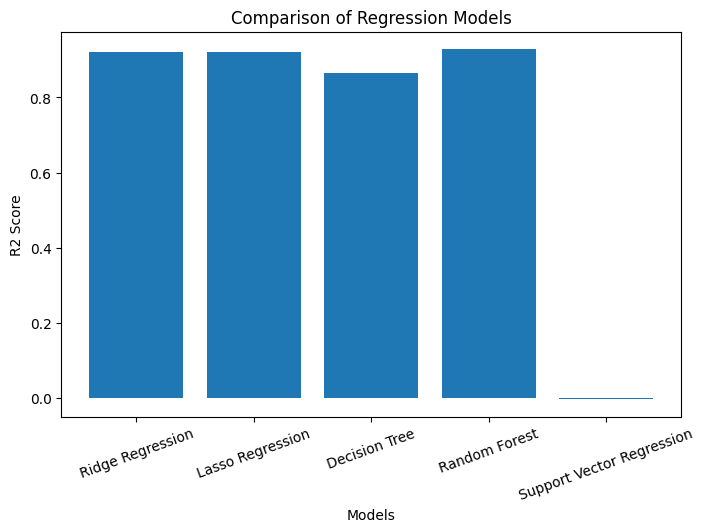

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["R2 Score"])

plt.title("Comparison of Regression Models")

plt.xlabel("Models")

plt.ylabel("R2 Score")

plt.xticks(rotation=20)

plt.show()

In [ ]:
best_model = comparison.loc[
    comparison["R2 Score"].idxmax()
]

print("Best Performing Model")

print(best_model)

Best Performing Model
Model        Random Forest
MAE         1753015.219211
RMSE        2400226.586259
R2 Score          0.928465
Name: 3, dtype: object
